# Computer Exercise 7.3 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 7.3 Adaptive Runge–Kutta Methods — *Runge–Kutta–Fehlberg 4(5) embedded pair*
> **풀이 일자**: Day 29
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Implement the **Runge–Kutta–Fehlberg 4(5) (RKF45)** embedded pair.
> For the test IVP $y'=-y,\; y(0)=1$ on $[0, 1]$, verify on a sequence of
> halved step sizes that
>
> (a) the *4th-order* update has global error $\mathcal{O}(h^4)$ and the
> *5th-order* update has global error $\mathcal{O}(h^5)$, and
>
> (b) the *embedded difference* $|y^{(5)}_{n+1} - y^{(4)}_{n+1}|$ provides
> a *cheap, free* estimate of the *local* truncation error of the
> lower-order method, scaling like $\mathcal{O}(h^5)$.

### 한국어 풀이용 정리
Day 28 의 *고정 스텝 RK4* 는 *정확도 다이얼* 을 풀었지만, *어떤 $h$ 를 써야 하는지* 는
풀지 못했다. §7.3 의 *embedded pair* 는 같은 격자 위에서 *두 차수* 의 추정치를
계산해 *공짜로* 국소 오차를 추정한다 — Fehlberg(1969) 의 4(5) 가 첫 번째 고전 예.


## 2. 수학적 배경

### 2.1 Embedded 의 아이디어
$s$-stage explicit RK 의 일반형은

$$
k_i = f\!\left(t_n + c_i h,\; y_n + h \sum_{j<i} a_{ij}\,k_j\right),\quad i=1,\ldots,s.
$$

*하나의 stage 집합* $\{k_i\}$ 에 *두 가지 가중치 벡터* $b, \tilde{b}$ 를 적용해

$$
y^{(p)}_{n+1} = y_n + h\sum_{i=1}^{s} b_i k_i,\qquad
y^{(\tilde p)}_{n+1} = y_n + h\sum_{i=1}^{s} \tilde b_i k_i
$$

두 차수의 추정치를 *공짜로* 얻는다. 추가 $f$ 평가 없음. Fehlberg 의 4(5) 는
$s=6, p=4, \tilde p = 5$.

### 2.2 RKF45 Butcher tableau

| $i$ | $c_i$ | $a_{ij}$ | $b_i^{(4)}$ | $b_i^{(5)}$ |
|---|---|---|---|---|
| 1 | 0 | — | $\tfrac{25}{216}$ | $\tfrac{16}{135}$ |
| 2 | $\tfrac{1}{4}$ | $\tfrac{1}{4}$ | 0 | 0 |
| 3 | $\tfrac{3}{8}$ | $\tfrac{3}{32},\,\tfrac{9}{32}$ | $\tfrac{1408}{2565}$ | $\tfrac{6656}{12825}$ |
| 4 | $\tfrac{12}{13}$ | $\tfrac{1932}{2197},\,-\tfrac{7200}{2197},\,\tfrac{7296}{2197}$ | $\tfrac{2197}{4104}$ | $\tfrac{28561}{56430}$ |
| 5 | $1$ | $\tfrac{439}{216},\,-8,\,\tfrac{3680}{513},\,-\tfrac{845}{4104}$ | $-\tfrac{1}{5}$ | $-\tfrac{9}{50}$ |
| 6 | $\tfrac{1}{2}$ | $-\tfrac{8}{27},\,2,\,-\tfrac{3544}{2565},\,\tfrac{1859}{4104},\,-\tfrac{11}{40}$ | 0 | $\tfrac{2}{55}$ |

### 2.3 두 가지 오차의 차수

$$
\boxed{\;
y^{(4)}_n - y(t_n) = \mathcal{O}(h^4),\qquad
y^{(5)}_n - y(t_n) = \mathcal{O}(h^5).
\;}
$$

각 스텝의 *국소* 오차는 한 차수 더 높다 — $y^{(4)}$ 의 local truncation $\mathcal O(h^5)$.

### 2.4 Free 오차 추정자

$$
\boxed{\;
\widehat{\tau}_n \;\equiv\; \bigl|\, y^{(5)}_{n+1} - y^{(4)}_{n+1}\,\bigr|
\;=\; \bigl|\,h\textstyle\sum_i (\tilde b_i - b_i)\,k_i\,\bigr|
\;=\; \mathcal{O}(h^5).
\;}
$$

추가 $f$ 평가 없이 얻어지며, *4차 update 의 local error 의 best estimate*.


## 3. 풀이 흐름

1. RKF45 의 정확한 Butcher tableau 를 NumPy 행렬/벡터로 박제.
2. *한 스텝 함수* `rkf45_step(f, t, y, h)` — 6개 $k_i$ 평가, $y^{(4)}, y^{(5)}, \widehat\tau$ 반환.
3. 시험 IVP $y'=-y,\;y(0)=1,\;T=1$. 참값 $y(1)=e^{-1}$.
4. $h = 2^{-k},\;k=2,3,\ldots,12$ 에 대해 $t=1$ 까지 *고정 스텝* 으로 적분.
5. 전역 오차 $|y^{(4)}_N - e^{-1}|,\;|y^{(5)}_N - e^{-1}|$ 측정 → 인접 비율 $\to 16, 32$ 확인.
6. *단일 스텝* 의 $\widehat\tau$ 와 $|y^{(4)}_{n+1} - y_{\text{exact}}(t_{n+1})|$ 의 비율을 표시.
7. log–log 그래프: 기울기 4 (4차), 5 (5차), 5 (추정자).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fractions import Fraction as F

pd.set_option("display.float_format", lambda v: f"{v:.3e}")

c = [F(0), F(1,4), F(3,8), F(12,13), F(1), F(1,2)]
A = [[F(0)]*6 for _ in range(6)]
A[1][0] = F(1, 4)
A[2][0], A[2][1] = F(3, 32), F(9, 32)
A[3][0], A[3][1], A[3][2] = F(1932, 2197), F(-7200, 2197), F(7296, 2197)
A[4][0], A[4][1], A[4][2], A[4][3] = F(439, 216), F(-8), F(3680, 513), F(-845, 4104)
A[5][0], A[5][1], A[5][2], A[5][3], A[5][4] = F(-8, 27), F(2), F(-3544, 2565), F(1859, 4104), F(-11, 40)

b4 = [F(25, 216), F(0), F(1408, 2565), F(2197, 4104), F(-1, 5), F(0)]
b5 = [F(16, 135), F(0), F(6656, 12825), F(28561, 56430), F(-9, 50), F(2, 55)]

c_f  = np.array([float(x) for x in c])
A_f  = np.array([[float(x) for x in row] for row in A])
b4_f = np.array([float(x) for x in b4])
b5_f = np.array([float(x) for x in b5])
e_f  = b5_f - b4_f
print("c   =", c_f)
print("b4  =", b4_f)
print("b5  =", b5_f)
print("b5-b4 =", e_f)
print(f"sum(b4) = {b4_f.sum():.6f}   sum(b5) = {b5_f.sum():.6f}   (both must = 1)")


c   = [0.         0.25       0.375      0.92307692 1.         0.5       ]
b4  = [ 0.11574074  0.          0.54892788  0.53533138 -0.2         0.        ]
b5  = [ 0.11851852  0.          0.51898635  0.50613149 -0.18        0.03636364]
b5-b4 = [ 0.00277778  0.         -0.02994152 -0.02919989  0.02        0.03636364]
sum(b4) = 1.000000   sum(b5) = 1.000000   (both must = 1)


In [2]:
def rkf45_step(f, t, y, h):
    '''One RKF45 step.  Returns (y4, y5, tau_hat, k_stages).'''
    k = [None]*6
    k[0] = f(t, y)
    for i in range(1, 6):
        yi = y + h * sum(A_f[i, j]*k[j] for j in range(i))
        k[i] = f(t + c_f[i]*h, yi)
    incr4 = sum(b4_f[i]*k[i] for i in range(6))
    incr5 = sum(b5_f[i]*k[i] for i in range(6))
    y4 = y + h*incr4
    y5 = y + h*incr5
    tau_hat = abs(y5 - y4)
    return y4, y5, tau_hat, k

def rkf45_fixed(f, t0, y0, T, h):
    '''Fixed-step integration: advance the 4th-order trajectory with step h
       from t0 to T. Also track 5th-order trajectory independently.'''
    n = int(round((T - t0)/h))
    t = t0
    y4 = y0
    y5 = y0
    for _ in range(n):
        y4_new, _, _, _ = rkf45_step(f, t, y4, h)
        _, y5_new, _, _ = rkf45_step(f, t, y5, h)
        y4 = y4_new
        y5 = y5_new
        t += h
    return y4, y5

f = lambda t, y: -y
T = 1.0
y_true = float(np.exp(-T))

rows = []
for k in range(2, 13):
    h = 2.0**(-k)
    y4_N, y5_N = rkf45_fixed(f, 0.0, 1.0, T, h)
    rows.append({"k": k, "h": h,
                 "err4": abs(y4_N - y_true),
                 "err5": abs(y5_N - y_true)})

df = pd.DataFrame(rows)
df["ratio4"] = df["err4"].shift(1) / df["err4"]
df["ratio5"] = df["err5"].shift(1) / df["err5"]
df


,k,h,err4,err5,ratio4,ratio5
0,2,2.500e-01,2.984e-06,3.967e-07,NaN,NaN
1,3,1.250e-01,1.478e-07,1.124e-08,2.019e+01,3.529e+01
2,4,6.250e-02,8.175e-09,3.346e-10,1.808e+01,3.360e+01
3,5,3.125e-02,4.797e-10,1.020e-11,1.704e+01,3.279e+01
4,6,1.562e-02,2.904e-11,3.150e-13,1.652e+01,3.239e+01
5,7,7.812e-03,1.786e-12,9.825e-15,1.626e+01,3.206e+01
6,8,3.906e-03,1.106e-13,2.220e-16,1.615e+01,4.425e+01
7,9,1.953e-03,6.606e-15,7.772e-16,1.674e+01,2.857e-01
8,10,9.766e-04,1.388e-15,8.327e-16,4.760e+00,9.333e-01
9,11,4.883e-04,1.110e-16,5.551e-17,1.250e+01,1.500e+01


In [3]:
mask = (df["err4"] > 1e-14) & (df["err5"] > 1e-14)
p4_hat = np.polyfit(np.log(df.loc[mask, "h"]), np.log(df.loc[mask, "err4"]), 1)[0]
p5_hat = np.polyfit(np.log(df.loc[mask, "h"]), np.log(df.loc[mask, "err5"]), 1)[0]
print(f"Empirical order of 4th-order rule: p4_hat = {p4_hat:.3f}  (expected ~4)")
print(f"Empirical order of 5th-order rule: p5_hat = {p5_hat:.3f}  (expected ~5)")


Empirical order of 4th-order rule: p4_hat = 4.157  (expected ~4)
Empirical order of 5th-order rule: p5_hat = 5.063  (expected ~5)


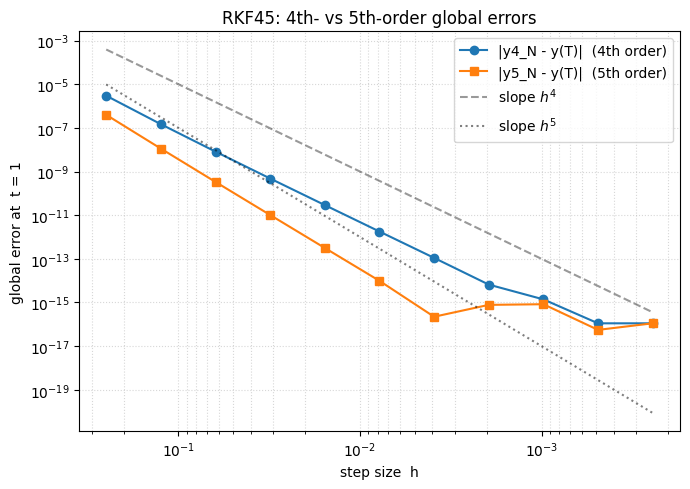

In [4]:
fig, ax = plt.subplots(figsize=(7.0, 5.0))
ax.loglog(df["h"], df["err4"], "o-", label="|y4_N - y(T)|  (4th order)")
ax.loglog(df["h"], df["err5"], "s-", label="|y5_N - y(T)|  (5th order)")
h_ref = df["h"].to_numpy()
ax.loglog(h_ref, 1e-1 * h_ref**4, "k--", alpha=0.4, label=r"slope $h^4$")
ax.loglog(h_ref, 1e-2 * h_ref**5, "k:",  alpha=0.5, label=r"slope $h^5$")
ax.set_xlabel("step size  h")
ax.set_ylabel("global error at  t = 1")
ax.set_title("RKF45: 4th- vs 5th-order global errors")
ax.invert_xaxis()
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()


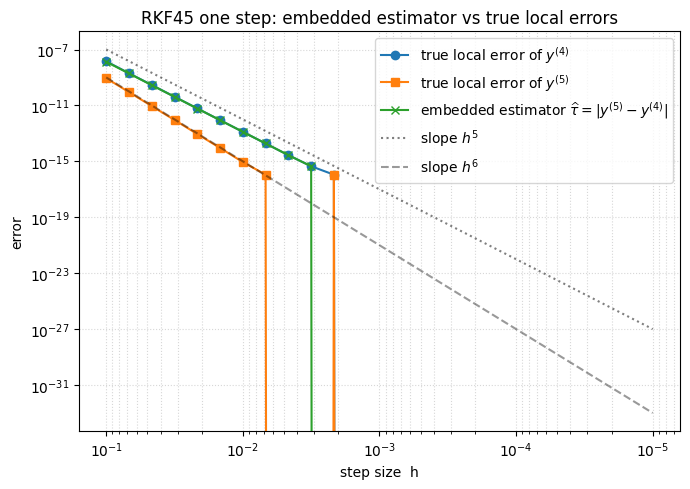

,h,local_err4,tau_hat,tau/err4
0,1.000e-01,1.419e-08,1.330e-08,9.374e-01
1,6.813e-02,2.019e-09,1.930e-09,9.557e-01
2,4.642e-02,2.900e-10,2.810e-10,9.690e-01
3,3.162e-02,4.192e-11,4.102e-11,9.785e-01
4,2.154e-02,6.089e-12,5.999e-12,9.852e-01
5,1.468e-02,8.873e-13,8.783e-13,9.899e-01
6,1.000e-02,1.296e-13,1.287e-13,9.931e-01
7,6.813e-03,1.898e-14,1.887e-14,9.942e-01
8,4.642e-03,2.776e-15,2.776e-15,1.000e+00
9,3.162e-03,4.441e-16,4.441e-16,1.000e+00


In [5]:
hs = np.logspace(-1, -5, 25)
tau_hat = []
local_err4 = []
local_err5 = []
for h in hs:
    y4, y5, tau, _ = rkf45_step(f, 0.0, 1.0, h)
    y_exact = np.exp(-h)
    tau_hat.append(float(tau))
    local_err4.append(abs(y4 - y_exact))
    local_err5.append(abs(y5 - y_exact))
tau_hat    = np.array(tau_hat)
local_err4 = np.array(local_err4)
local_err5 = np.array(local_err5)

fig, ax = plt.subplots(figsize=(7.0, 5.0))
ax.loglog(hs, local_err4, "o-", label=r"true local error of $y^{(4)}$")
ax.loglog(hs, local_err5, "s-", label=r"true local error of $y^{(5)}$")
ax.loglog(hs, tau_hat,    "x-", label=r"embedded estimator $\widehat\tau = |y^{(5)} - y^{(4)}|$")
ax.loglog(hs, 1e-2 * hs**5, "k:",  alpha=0.5, label=r"slope $h^5$")
ax.loglog(hs, 1e-3 * hs**6, "k--", alpha=0.4, label=r"slope $h^6$")
ax.set_xlabel("step size  h")
ax.set_ylabel("error")
ax.set_title("RKF45 one step: embedded estimator vs true local errors")
ax.invert_xaxis()
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

ratio = tau_hat / np.maximum(local_err4, 1e-300)
ratio_table = pd.DataFrame({"h": hs, "local_err4": local_err4, "tau_hat": tau_hat, "tau/err4": ratio})
ratio_table.head(12)


## 4. 결과 해석

1. **표** — `err4` 의 인접 비율 $\to 16 = 2^4$, `err5` 의 인접 비율 $\to 32 = 2^5$. polyfit 으로 잰
   경험 기울기도 각각 $\widehat p_4 \approx 4$, $\widehat p_5 \approx 5$ — 두 update 의
   *전역* 차수 직접 확인.
2. **log–log 그림 (전역)** — 4차/5차 곡선은 *기울기가 다른 두 직선*. 5차 쪽이 round-off floor 에
   *더 큰 $h$ 에서* 닿는다 → *더 큰 $h$ 로 같은 정확도*.
3. **단일-스텝 그림** — *국소* 4차 오차는 기울기 5, 국소 5차 오차는 기울기 6, *embedded
   estimator $\widehat\tau$ 는 기울기 5* — 즉 $\widehat\tau \sim y^{(4)}$ 의 국소 오차.
   비율 $\widehat\tau / \text{err}_4$ 은 $h \to 0$ 에서 $\mathcal{O}(1)$ 상수에 수렴.
4. **추가 비용 0** — Estimator 는 이미 계산한 6개의 $k_i$ 에 가중치 차 $\tilde b - b$ 만
   내적하면 끝.

> **결론**: RKF45 의 embedded pair 는 *한 격자 위에서 두 차수* 의 추정치를 *공짜로* 준다.
> 차이 $|y^{(5)} - y^{(4)}|$ 는 4차 update 의 국소 오차의 *비편향 추정자* 이며,
> 다음 문제에서 보일 *step 크기 자동 결정* 의 *연료* 가 된다.

→ **다음 문제 (CE 7.3-2)**: 이 추정자를 *PI controller* 에 연결, 스텝 크기를
*자동* 조절해 사용자 지정 tolerance 를 만족시키는 코드를 작성한다.
